In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

In [ ]:
listglioma=os.listdir('/content/drive/MyDrive/brain_tumour/glioma')
no_of_glioma_images =len(listglioma)

In [ ]:
listmeningioma=os.listdir('/content/drive/MyDrive/brain_tumour/meningioma')
no_of_meningioma_images=len(listmeningioma)

In [ ]:
listpituitary=os.listdir('/content/drive/MyDrive/brain_tumour/pituitary')
no_of_pituitary_images=len(listpituitary)

In [ ]:
listhealthy=os.listdir('/content/drive/MyDrive/brain_tumour/healthy')
no_of_healthy_images=len(listhealthy)

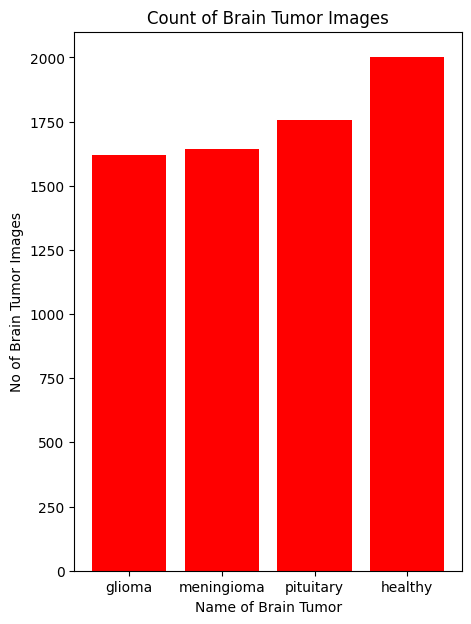

In [ ]:
data = {'glioma': no_of_glioma_images, 'meningioma': no_of_meningioma_images, 'pituitary':no_of_pituitary_images, 'healthy':no_of_healthy_images}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Name of Brain Tumor")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score

In [ ]:
import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf

In [ ]:
import os
import cv2

X = []
Y = []
image_size = 150
labels = ['glioma', 'healthy', 'meningioma', 'pituitary']
for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/brain_tumour/', i)
    for j in os.listdir(folderPath):
        # Check if the current item is a file and not a directory to avoid trying to read directories as images.
        if os.path.isfile(os.path.join(folderPath, j)):
            img = cv2.imread(os.path.join(folderPath, j))
            # Check if the image was loaded successfully before resizing.
            if img is not None:
                img = cv2.resize(img, (image_size, image_size))
                X.append(img)
                Y.append(i)
            else:
                print(f"Failed to load image: {os.path.join(folderPath, j)}") # Print an error message if an image fails to load

In [ ]:
X= np.array(X)
Y= np.array(Y)

glioma


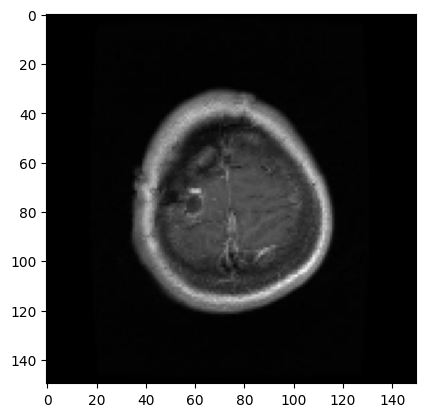

glioma


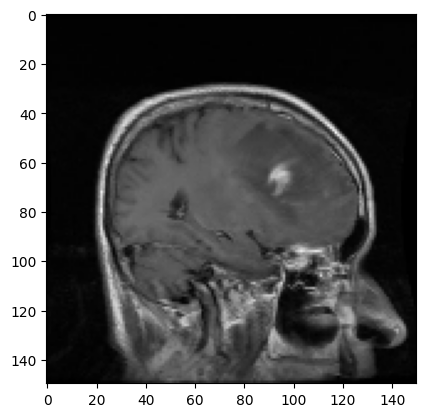

glioma


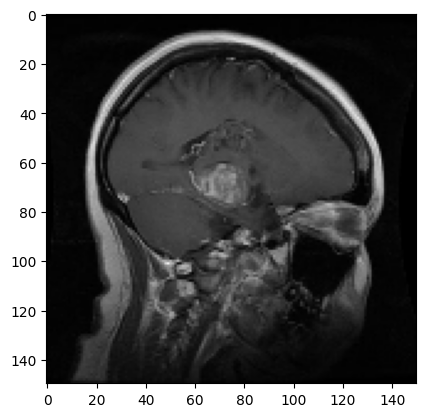

glioma


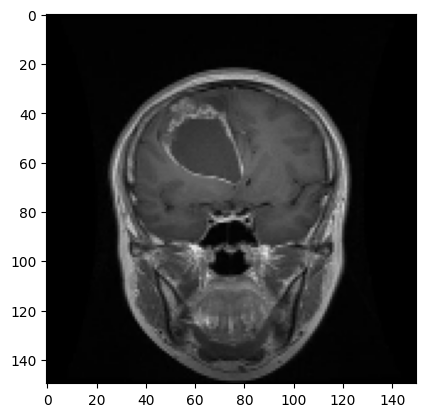

glioma


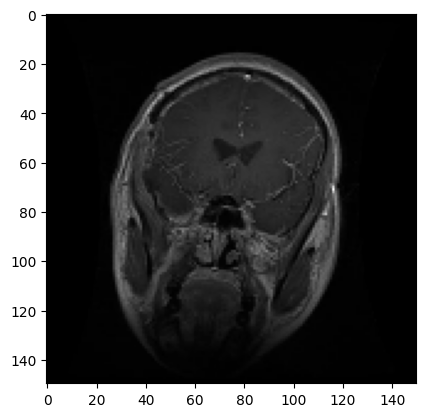

glioma


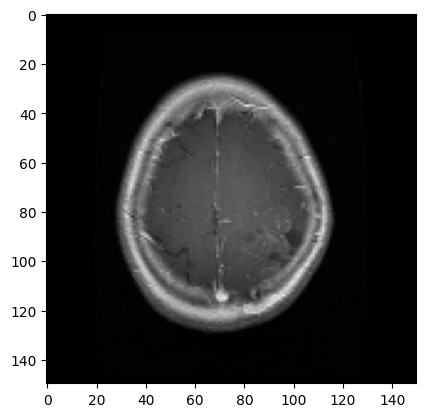

glioma


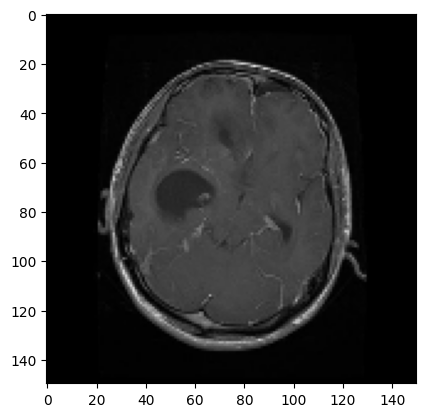

glioma


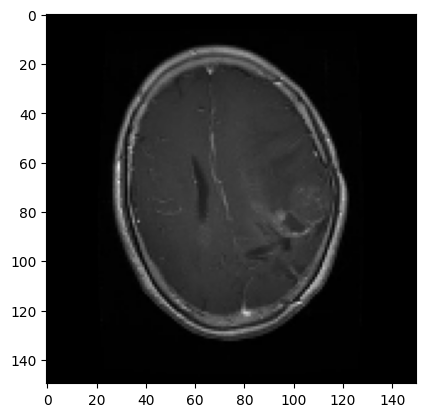

glioma


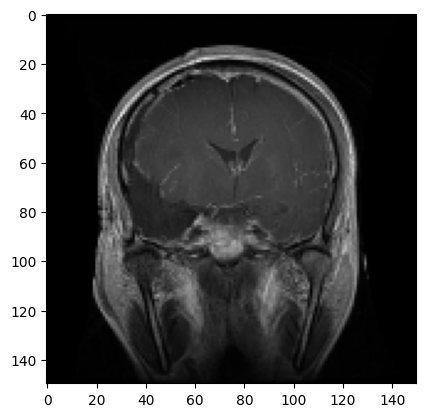

glioma


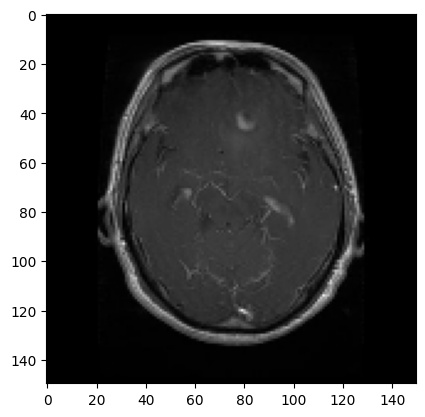

In [ ]:
for i in range(10):
    plt.imshow(X[i])
    print(Y[i])
    plt.show()

meningioma


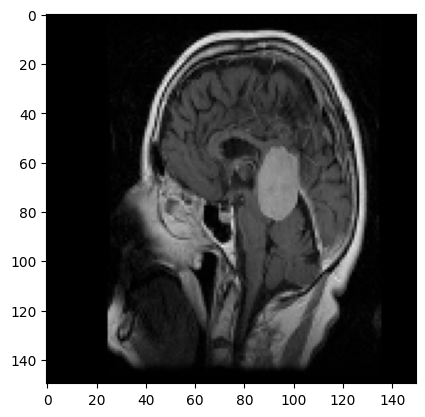

healthy


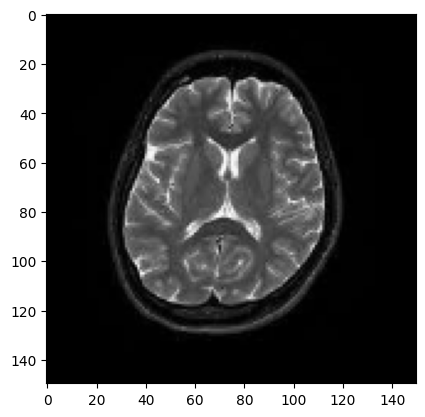

healthy


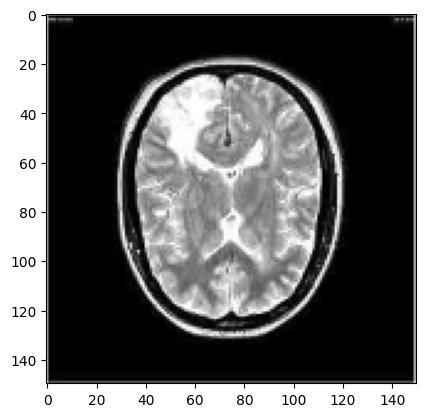

healthy


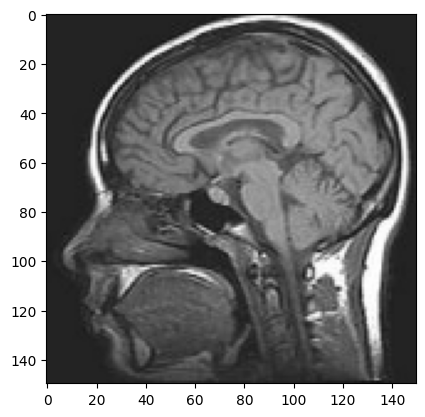

healthy


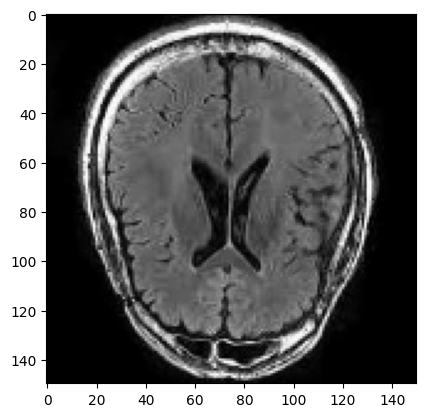

pituitary


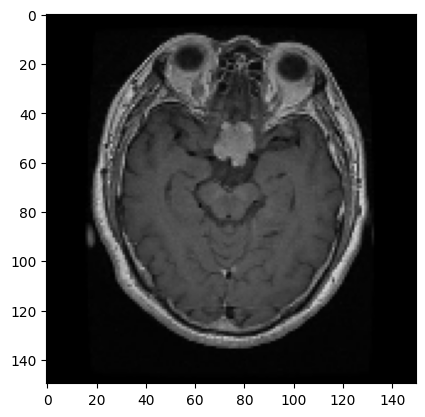

pituitary


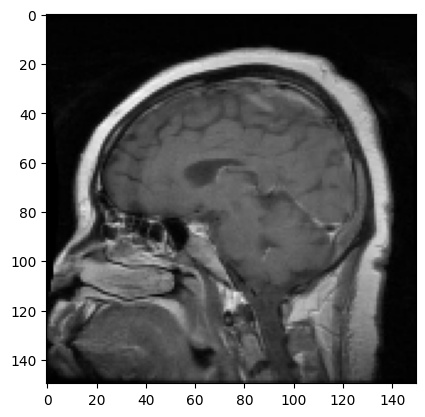

meningioma


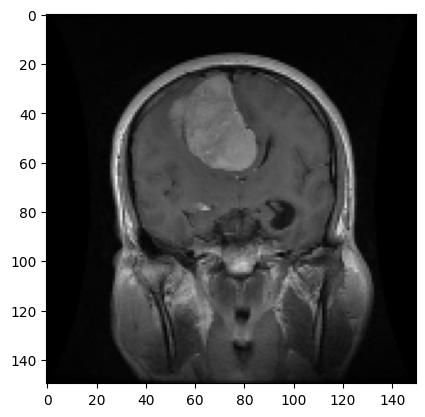

meningioma


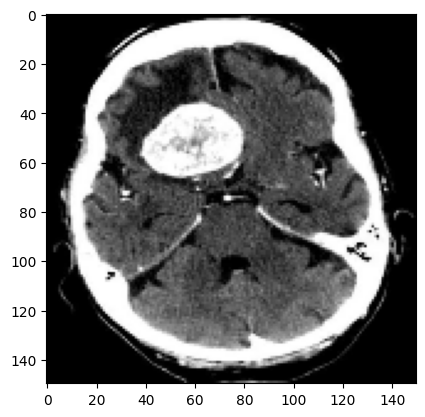

pituitary


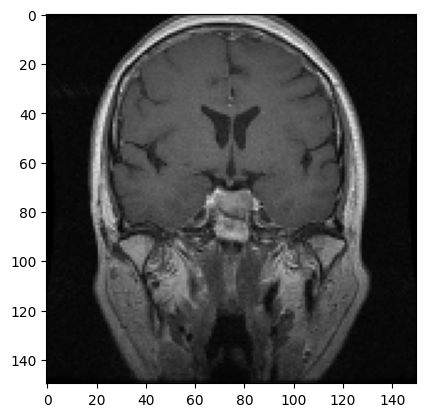

In [ ]:
import random
for i in random.sample(range(len(X)), 10): # Generate 10 unique random indices within the range of X's length
    plt.imshow(X[i])
    print(Y[i])
    plt.show()

In [ ]:
X,Y = shuffle(X,Y, random_state=100) #initially we appended x and Y value from each folder, the labels and images will be in ordered, so we used shuffle method to shuffle the dataset

healthy


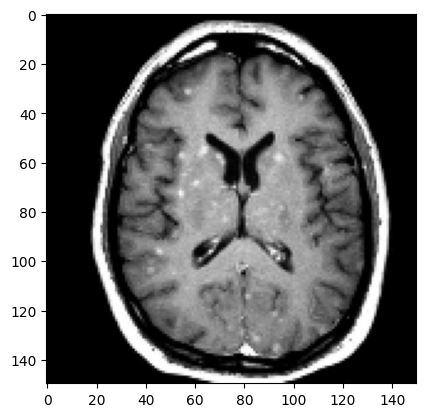

pituitary


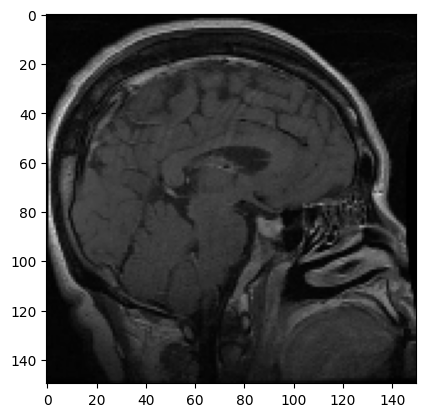

meningioma


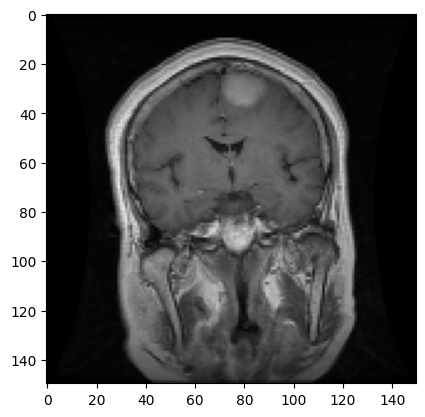

meningioma


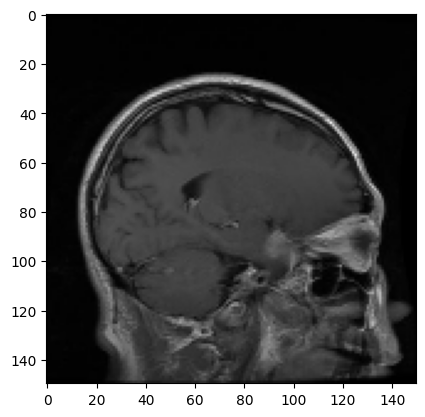

healthy


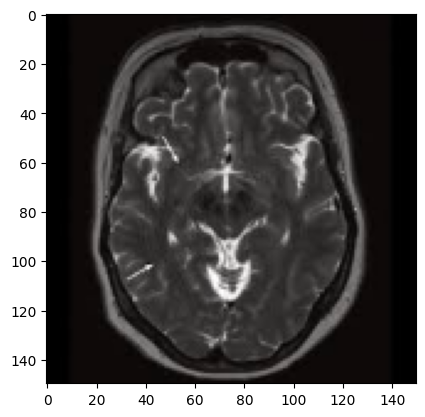

meningioma


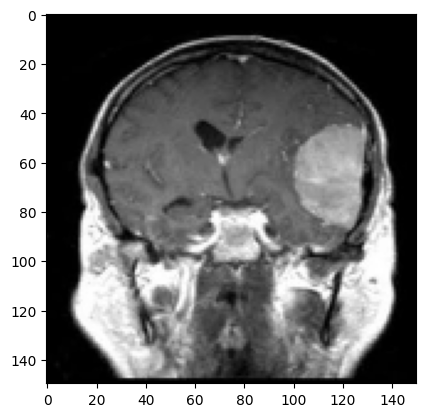

healthy


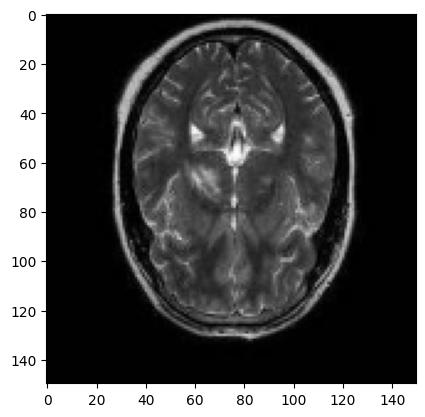

pituitary


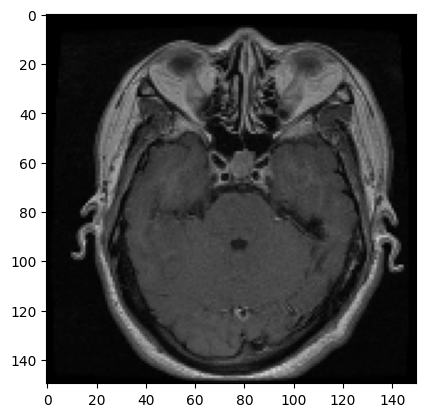

meningioma


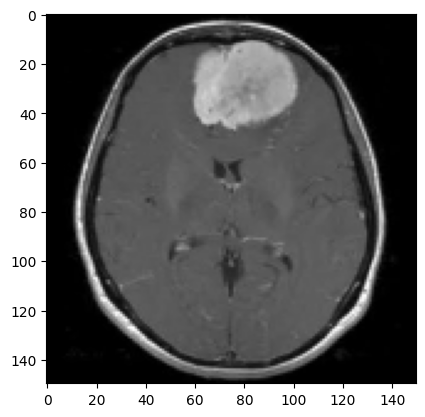

meningioma


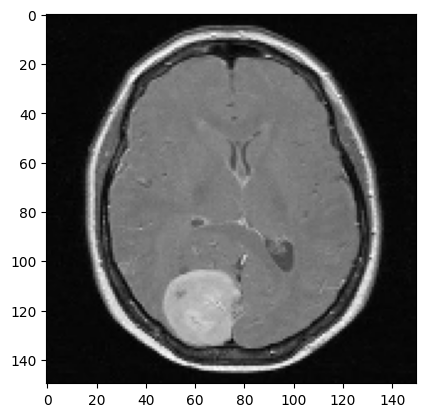

In [ ]:
for i in range(10):# checking whether the dataset is shuffled
    plt.imshow(X[i])
    print(Y[i])
    plt.show()

In [ ]:
X.shape  #determines (no.of images, height,width,no.of channels)

(7023, 150, 150, 3)

In [ ]:
Y.shape

(7023,)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=100)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((5618, 150, 150, 3), (1405, 150, 150, 3), (5618,), (1405,))

In [ ]:
pd.Series(y_train).value_counts()

,count
healthy,1585
pituitary,1414
meningioma,1320
glioma,1299


In [ ]:
pd.Series(y_test).value_counts()

,count
healthy,415
pituitary,343
meningioma,325
glioma,322


In [ ]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train=y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test=y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [ ]:
y_train_new=np.array(y_train_new)
y_test_new=np.array(y_test_new)

In [ ]:
y_train_new.shape,y_test_new.shape

((5618,), (1405,))

Convolutional Neural Network

In [ ]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape=(150,150,3)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 146, 146, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 69, 69, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 69, 69, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 30, 30, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 10, 10, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,447,044 (16.96 MB)

 Trainable params: 4,447,044 (16.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
y_train_new = tf.keras.utils.to_categorical(y_train_new, num_classes=4)
history = model.fit(X_train,y_train_new,epochs=40,validation_split=0.1)


Epoch 1/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 1020s 6s/step - accuracy: 0.3287 - loss: 1.8044 - val_accuracy: 0.5018 - val_loss: 1.1558
Epoch 2/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 1028s 6s/step - accuracy: 0.5894 - loss: 0.9373 - val_accuracy: 0.6495 - val_loss: 0.8236
Epoch 3/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 1000s 6s/step - accuracy: 0.7593 - loss: 0.5844 - val_accuracy: 0.6744 - val_loss: 0.7545
Epoch 4/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 1012s 6s/step - accuracy: 0.7891 - loss: 0.5069 - val_accuracy: 0.7758 - val_loss: 0.5125
Epoch 5/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 1031s 6s/step - accuracy: 0.8151 - loss: 0.4552 - val_accuracy: 0.7420 - val_loss: 0.6869
Epoch 6/40
113/158 ━━━━━━━━━━━━━━━━━━━━ 4:35 6s/step - accuracy: 0.8515 - loss: 0.3738

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

In [ ]:
acc = accuracy_score(y_test_new,np.argmax(y_pred,axis=1))
acc

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test_new,np.argmax(y_pred,axis=1))

In [ ]:
# Create the ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot()
plt.show()

In [ ]:
# labels = ['glioma', 'healthy', 'meningioma', 'pituitary']
# numerical=[0,1,2,3]
image=cv2.imread("/content/meningioma/0000.jpg")
print(plt.imshow(image))
image=cv2.resize(image,(150,150))
image=np.array(image)
image=image.reshape(1,150,150,3)

In [ ]:
image.shape

In [ ]:
a=model.predict(image)
indices = a.argmax()
indices
for i in range(len(labels)):
  if indices==i:
    print(labels[i])

In [ ]:
image=cv2.imread("/content/healthy/0008.jpg")
print(plt.imshow(image))
image=cv2.resize(image,(150,150))
image=np.array(image)
image=image.reshape(1,150,150,3)

In [ ]:
a=model.predict(image)
indices = a.argmax()
indices
for i in range(len(labels)):
  if indices==i:
    print(labels[i])

In [ ]:
plt.imshow(X_test[100])

In [ ]:
y_test[100]

In [ ]:
image = X_test[100].astype('float32')  # Change data type to float32
image = image.reshape(1, 150, 150, 3)  # Reshape to include batch dimension

a = model.predict(image)  # Now predict using the reshaped image

indices = a.argmax()
indices

for i in range(len(labels)):
  if indices == i:
    print(labels[i])

In [ ]:
from sklearn.svm import SVC
svc_model = SVC(kernel='linear') # You can experiment with different kernels

# Make predictions on the test data

In [ ]:
svc_model.fit(X_train.reshape(-1, 150 * 150 * 3), y_train)